# Student Mental Health & Burnout Analysis

Author: Gauri Gupta

## Objective

The goal of this project is to identify the factors that influence student mental health, burnout, and dropout risk using exploratory data analysis and statistical insights.

Key Questions:

1. What factors affect student mental health?
2. What drives burnout among students?
3. What factors contribute to dropout risk?
4. How does stress impact overall student well-being?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("All libraries are imported")

All libraries are imported


## Loading Dataset

In [2]:
df = pd.read_csv("student_mental_health_burnout_1M.csv")
print("Data is loaded")
df.head(10)

Data is loaded


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000
5,29,Female,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,Low,2.731063
6,21,Female,3,7.012742,7.287667,75.180787,2.989919,1.445026,0.000000,3.660558,1.975417,7.048037,6.502918,6.769425,4.811232,1.130250,1.798278,8.370524,Low,0.868724
7,23,Female,2,6.946342,7.501935,80.894906,5.007514,2.725366,0.782428,7.355030,0.000000,4.270020,3.618190,2.170218,5.428043,6.732679,1.939261,6.944656,Low,1.578051
8,26,Male,4,6.535580,6.910609,77.236996,5.802609,4.451598,2.034520,5.157029,2.138839,3.340810,1.534403,2.106578,6.578510,5.831068,3.535596,5.733121,Medium,3.492676
9,19,Female,3,5.292718,6.621179,73.808178,4.307115,2.435479,1.127562,6.281727,0.991039,9.161838,4.628498,2.059240,3.826165,4.525573,0.000000,7.208242,Low,0.446036


## Dataset Overview

Let's examine the size, structure, and quality of the dataset.

In [3]:
print("Data Shape:", df.shape)
df.info()

Data Shape: (595116, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595116 entries, 0 to 595115
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   595116 non-null  int64  
 1   gender                595116 non-null  object 
 2   academic_year         595116 non-null  int64  
 3   study_hours_per_day   595115 non-null  float64
 4   exam_pressure         595115 non-null  float64
 5   academic_performance  595115 non-null  float64
 6   stress_level          595115 non-null  float64
 7   anxiety_score         595115 non-null  float64
 8   depression_score      595115 non-null  float64
 9   sleep_hours           595115 non-null  float64
 10  physical_activity     595115 non-null  float64
 11  social_support        595115 non-null  float64
 12  screen_time           595115 non-null  float64
 13  internet_usage        595115 non-null  float64
 14  financial_stress      59511

In [4]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,595116.000000,595116.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000,595115.000000
mean,22.995228,2.501175,5.001868,5.999516,70.996908,4.246604,2.985227,1.274420,6.501946,3.011711,5.001697,5.017917,5.036371,5.001749,5.983200,1.783741,7.023464,1.323744
std,3.741902,1.118088,1.988939,1.548132,5.657795,1.677819,1.509104,1.221264,1.472730,1.462176,1.976332,1.959860,2.158434,1.976973,1.959641,1.662756,1.309879,1.341959
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650225,4.947344,67.173191,3.105228,1.922825,0.005076,5.491092,1.993734,3.651957,3.649126,3.487717,3.655316,4.646556,0.126053,6.143271,0.000000
50%,23.000000,3.000000,5.001263,6.000461,70.994846,4.244028,2.968368,1.047659,6.502784,3.001841,5.001817,5.003261,5.000103,5.000663,5.997792,1.498473,7.074595,1.008541
75%,26.000000,4.000000,6.344565,7.053478,74.818751,5.384106,4.013090,2.084392,7.514826,4.009079,6.353556,6.348330,6.503701,6.354727,7.351576,2.888545,7.961551,2.169972
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.018870,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.212085


In [5]:
df.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,1
exam_pressure,1
academic_performance,1
stress_level,1
anxiety_score,1
depression_score,1
sleep_hours,1


In [6]:
df.duplicated().sum()

np.int64(0)

### Observations

- Dataset contains 50,000 sampled student records.
- No missing values were found.
- No duplicate records were detected.
- Dataset contains academic, behavioral, and mental health related features.

## Understanding Target Variables

We first examine the distribution of key outcome variables.

In [7]:
#target variables

targets = [
    "mental_health_index",
    "burnout_score",
    "dropout_risk"
]

for col in targets:
    print("\n")
    print(col)
    print(df[col].describe())



mental_health_index
count    595115.000000
mean          7.023464
std           1.309879
min           1.309745
25%           6.143271
50%           7.074595
75%           7.961551
max          10.000000
Name: mental_health_index, dtype: float64


burnout_score
count    595115.000000
mean          1.783741
std           1.662756
min           0.000000
25%           0.126053
50%           1.498473
75%           2.888545
max          10.000000
Name: burnout_score, dtype: float64


dropout_risk
count    595115.000000
mean          1.323744
std           1.341959
min           0.000000
25%           0.000000
50%           1.008541
75%           2.169972
max           9.212085
Name: dropout_risk, dtype: float64


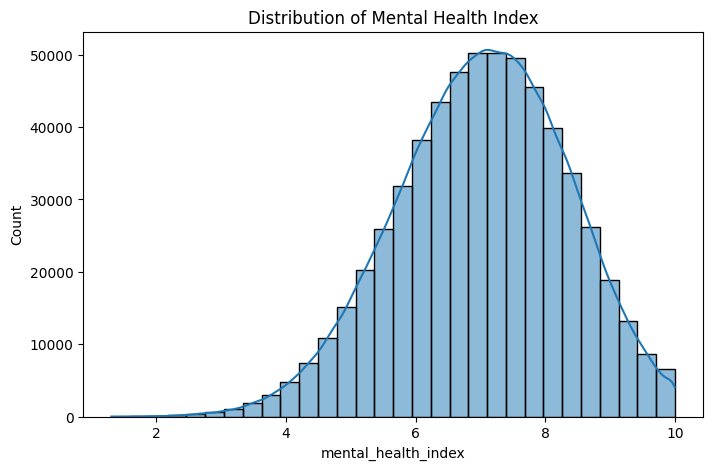

In [8]:
# distribution of mental health index
plt.figure(figsize=(8,5))

sns.histplot(
    df["mental_health_index"],
    bins=30,
    kde=True
)

plt.title("Distribution of Mental Health Index")
plt.show()

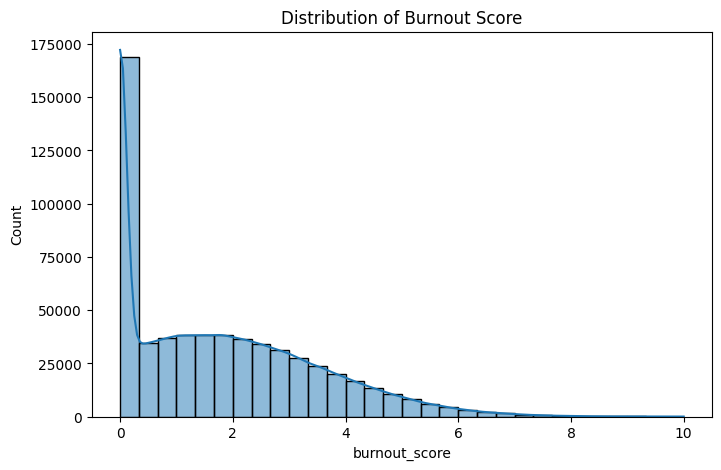

In [9]:
# distribution of burnout score

plt.figure(figsize=(8,5))

sns.histplot(
    df["burnout_score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Burnout Score")
plt.show()

In [10]:
# risk level counts
df["risk_level"].value_counts()

,count
risk_level,
Low,456440
Medium,129803
High,8872


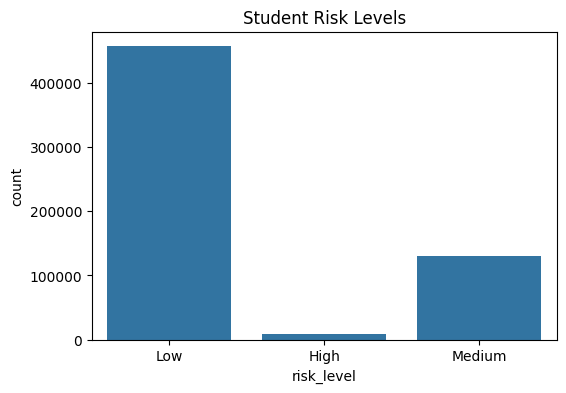

In [11]:
#risk level counts graph representaion

plt.figure(figsize=(6,4))

sns.countplot(
    x="risk_level",
    data=df
)

plt.title("Student Risk Levels")
plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between variables.

In [12]:
#correlation matrix
corr = df.corr(numeric_only=True)

corr

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
age,1.000000,-0.001432,-0.001236,-0.000775,0.000515,-0.001481,-0.001164,-0.002194,-0.001011,0.000870,-0.001363,0.000159,0.000656,-0.001170,-0.001085,-0.001434,0.001775,-0.001867
academic_year,-0.001432,1.000000,0.000947,0.000412,-0.000288,0.001633,0.000853,0.000682,-0.002241,-0.001930,0.000843,0.000539,0.000913,-0.001126,-0.000653,0.000232,-0.001322,-0.001500
study_hours_per_day,-0.001236,0.000947,1.000000,0.765678,0.388586,0.353513,0.269441,0.219923,-0.003907,-0.000322,0.000374,-0.000527,-0.001985,-0.000456,0.002520,0.335328,-0.335765,0.187271
exam_pressure,-0.000775,0.000412,0.765678,1.000000,0.127031,0.458808,0.349860,0.284285,-0.001443,0.000147,0.001206,0.000767,-0.000755,-0.000802,0.001786,0.433365,-0.435511,0.242376
academic_performance,0.000515,-0.000288,0.388586,0.127031,1.000000,0.059941,0.045434,0.036321,-0.001867,-0.002007,0.000809,-0.001132,-0.000925,-0.000552,-0.000829,0.057546,-0.056574,0.031821
stress_level,-0.001481,0.001633,0.353513,0.458808,0.059941,1.000000,0.760841,0.622240,-0.264095,-0.173597,-0.000030,-0.001115,-0.002216,0.467087,0.346713,0.753015,-0.949370,0.553389
anxiety_score,-0.001164,0.000853,0.269441,0.349860,0.045434,0.760841,1.000000,0.475733,-0.200669,-0.131721,-0.000746,-0.001486,-0.002337,0.353931,0.263851,0.668005,-0.868516,0.460329
depression_score,-0.002194,0.000682,0.219923,0.284285,0.036321,0.622240,0.475733,1.000000,-0.165646,-0.109910,-0.365751,0.000847,0.000056,0.290448,0.213443,0.642212,-0.762942,0.654250
sleep_hours,-0.001011,-0.002241,-0.003907,-0.001443,-0.001867,-0.264095,-0.200669,-0.165646,1.000000,0.000676,-0.000446,-0.000074,-0.000384,0.000227,-0.000034,-0.371974,0.251000,-0.191317
physical_activity,0.000870,-0.001930,-0.000322,0.000147,-0.002007,-0.173597,-0.131721,-0.109910,0.000676,1.000000,0.002904,0.000298,-0.000317,-0.000722,0.001541,-0.110175,0.165213,-0.070703


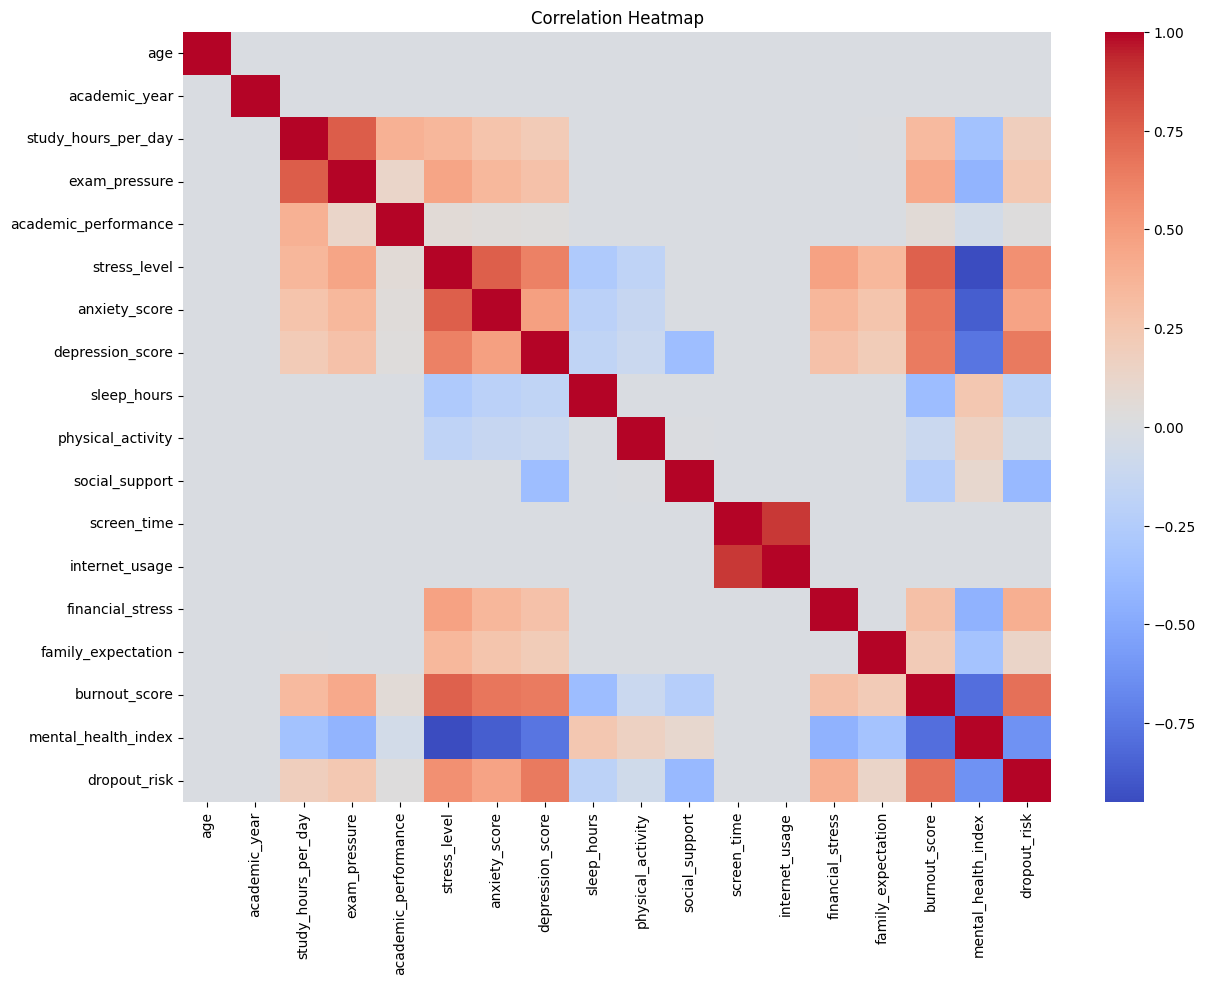

In [13]:
# heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

## Mental Health Drivers

In [14]:
# Factors affecting mental health

mh_corr = corr["mental_health_index"]

mh_corr.sort_values()

,mental_health_index
stress_level,-0.949370
anxiety_score,-0.868516
burnout_score,-0.796325
depression_score,-0.762942
dropout_risk,-0.625633
financial_stress,-0.442884
exam_pressure,-0.435511
study_hours_per_day,-0.335765
family_expectation,-0.328537
academic_performance,-0.056574


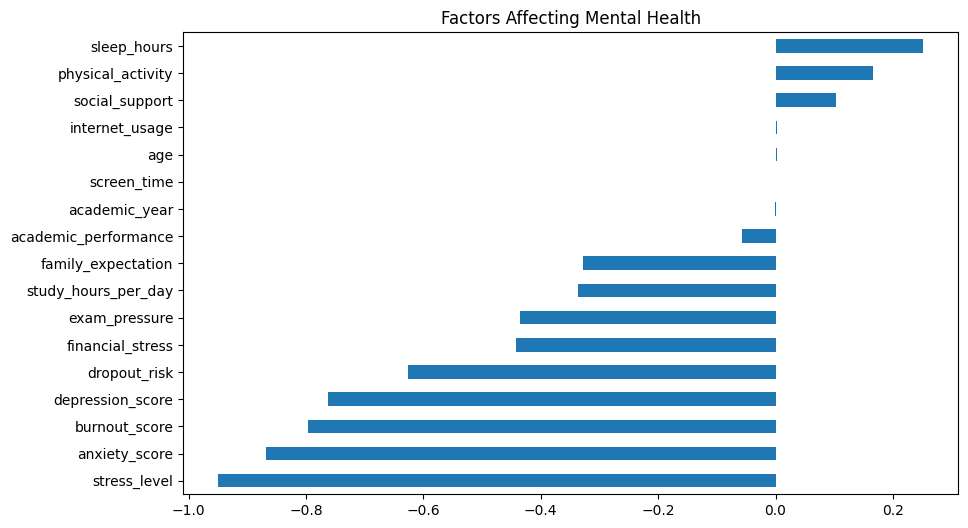

In [15]:
#top correlation
mh_corr.drop("mental_health_index")\
       .sort_values()\
       .plot(
            kind="barh",
            figsize=(10,6)
       )

plt.title("Factors Affecting Mental Health")
plt.show()

### Key Insight

Stress level showed the strongest negative relationship with mental health, followed by anxiety, burnout, and depression.

Sleep and physical activity demonstrated positive relationships with mental well-being.

## Stress and Student Well-Being

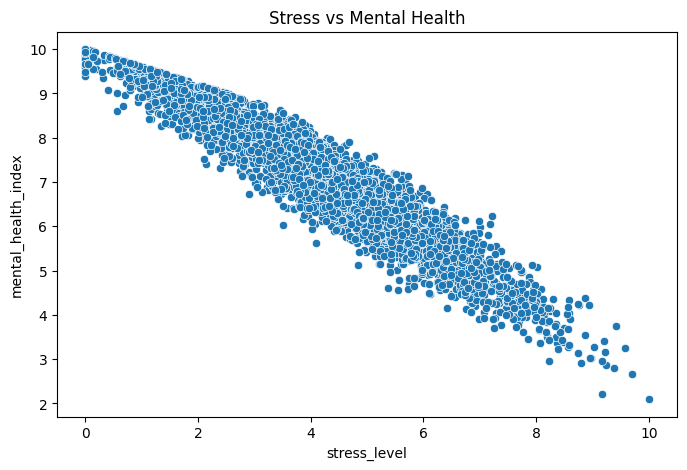

In [16]:
# Stress vs Mental health
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="stress_level",
    y="mental_health_index",
    data=df.sample(5000)
)

plt.title("Stress vs Mental Health")
plt.show()

In [17]:

# Stress Correlation
df[
    ["stress_level",
     "mental_health_index"]
].corr()

,stress_level,mental_health_index
stress_level,1.00000,-0.94937
mental_health_index,-0.94937,1.00000


### Key Insight

Mental health decreases sharply as stress levels increase.
Stress emerged as the strongest factor influencing student well-being.

## Sleep and Mental Health

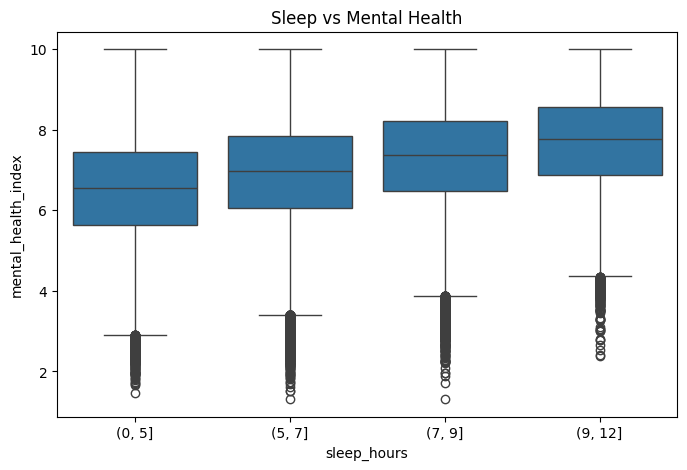

In [18]:
# Sleep vs mental health
plt.figure(figsize=(8,5))

sns.boxplot(
    x=pd.cut(
        df["sleep_hours"],
        bins=[0,5,7,9,12]
    ),
    y=df["mental_health_index"]
)

plt.title("Sleep vs Mental Health")
plt.show()

In [19]:
# Sleep correlation
df[
    ["sleep_hours",
     "mental_health_index"]
].corr()

,sleep_hours,mental_health_index
sleep_hours,1.000,0.251
mental_health_index,0.251,1.000


### Key Insight

Students sleeping longer generally reported better mental health and lower burnout.

## Physical Activity and Mental Health

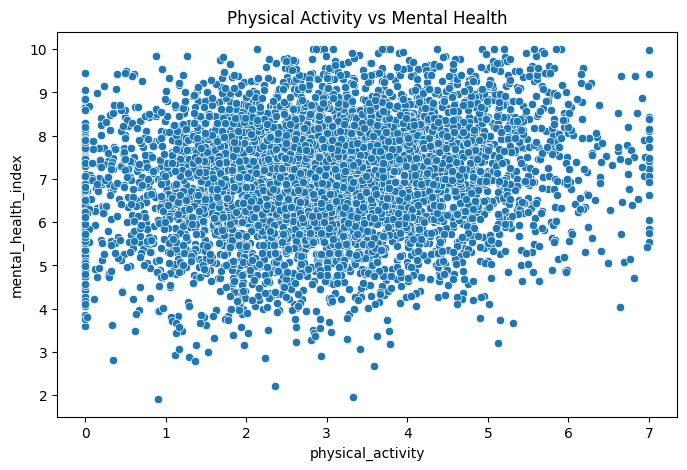

In [20]:
# Physical activity vs Mental health
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="physical_activity",
    y="mental_health_index",
    data=df.sample(5000)
)

plt.title("Physical Activity vs Mental Health")
plt.show()

### Key Insight

Physical activity showed a positive relationship with mental health, although weaker than stress and anxiety.

In [21]:
df = df.sample(5000, random_state=42)

## Financial Stress Impact

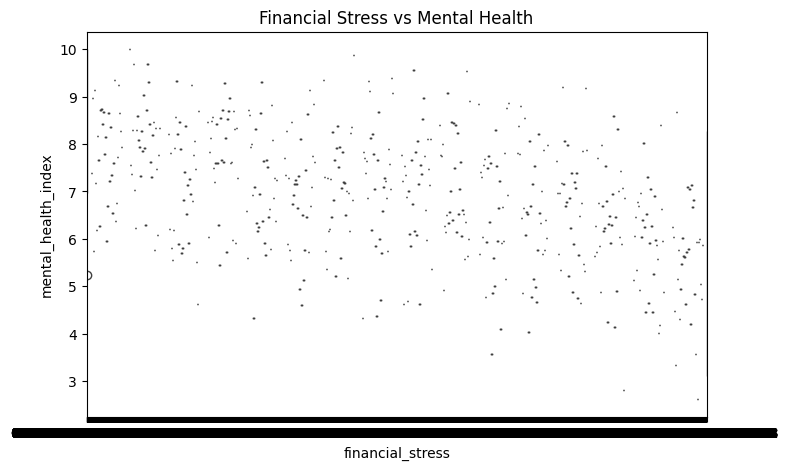

In [22]:
# Financial Stress analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x="financial_stress",
    y="mental_health_index",
    data=df
)

plt.title("Financial Stress vs Mental Health")
plt.show()

### Key Insight

Financial stress was associated with poorer mental health outcomes and increased dropout risk.

## Burnout Drivers

In [23]:
# Burnout
burnout_corr = corr["burnout_score"]

burnout_corr.sort_values()

,burnout_score
mental_health_index,-0.796325
sleep_hours,-0.371974
social_support,-0.229975
physical_activity,-0.110175
internet_usage,-0.002223
screen_time,-0.001597
age,-0.001434
academic_year,0.000232
academic_performance,0.057546
family_expectation,0.217205


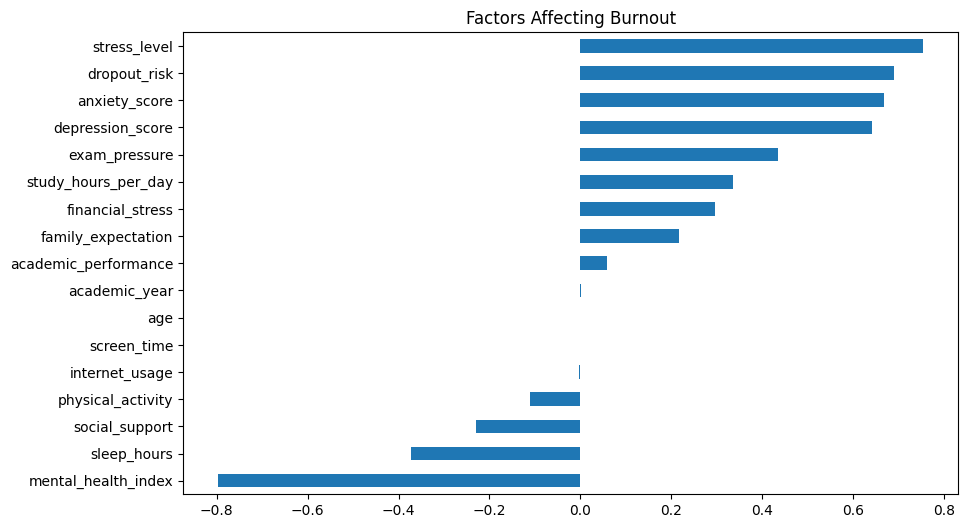

In [24]:
# Burnout correlation plot
burnout_corr.drop("burnout_score")\
            .sort_values()\
            .plot(
                kind="barh",
                figsize=(10,6)
            )

plt.title("Factors Affecting Burnout")
plt.show()

### Key Insight

Stress, anxiety, and depression were the strongest contributors to burnout.

In [25]:
# Risk Level
risk_profile = df.groupby(
    "risk_level"
).mean(
    numeric_only=True
)

risk_profile

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
risk_level,,,,,,,,,,,,,,,,,,
High,23.263889,2.527778,6.526551,7.569718,72.292265,7.444897,5.563238,3.561950,5.165037,2.406281,3.749896,5.212608,5.182951,6.646219,7.290912,6.639655,4.284485,4.344675
Low,23.024941,2.509583,4.672864,5.657542,70.839122,3.690015,2.540300,0.929885,6.724660,3.091735,5.149266,5.054202,5.038690,4.717814,5.832698,1.028435,7.482938,0.917685
Medium,22.874888,2.475424,5.832937,6.869305,71.389890,5.861639,4.306672,2.268574,5.791742,2.811094,4.442531,4.953004,4.948420,5.809639,6.448787,4.035073,5.682771,2.587027


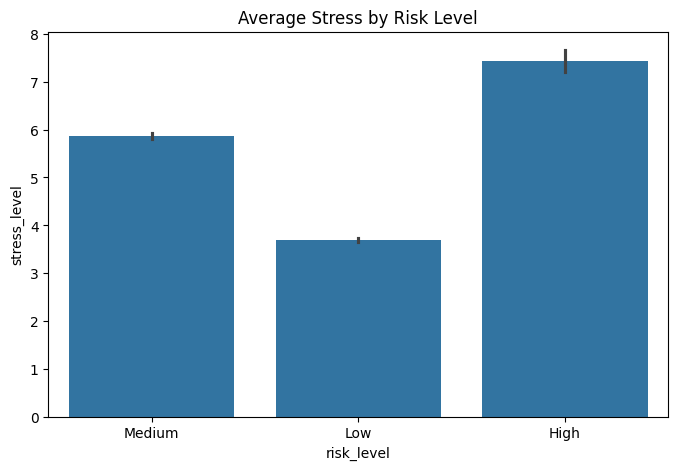

In [26]:
# Stress vs Risk Level
plt.figure(figsize=(8,5))

sns.barplot(
    x="risk_level",
    y="stress_level",
    data=df
)

plt.title("Average Stress by Risk Level")
plt.show()

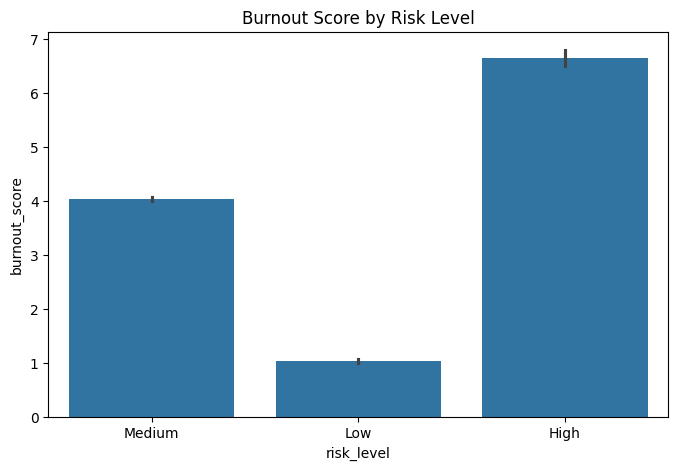

In [27]:
# Burnout vs Risk Level
plt.figure(figsize=(8,5))

sns.barplot(
    x="risk_level",
    y="burnout_score",
    data=df
)

plt.title("Burnout Score by Risk Level")
plt.show()

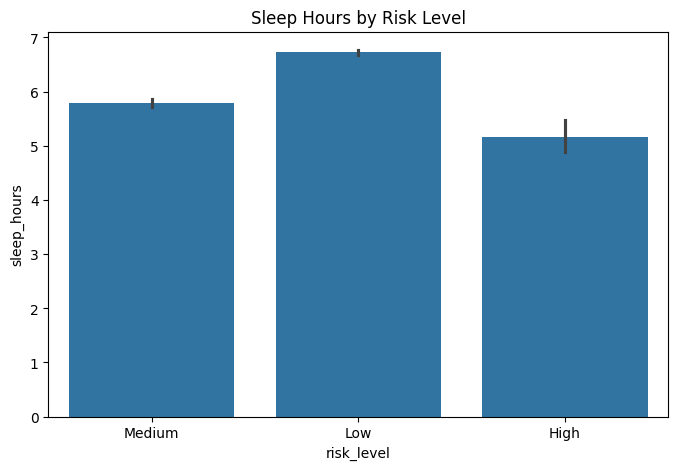

In [28]:
# Sleep vs Risk Level
plt.figure(figsize=(8,5))

sns.barplot(
    x="risk_level",
    y="sleep_hours",
    data=df
)

plt.title("Sleep Hours by Risk Level")
plt.show()

## Dropout Risk Drivers

In [29]:
# Dropout Risk Analysis
dropout_corr = corr["dropout_risk"]

dropout_corr.sort_values()

,dropout_risk
mental_health_index,-0.625633
social_support,-0.395256
sleep_hours,-0.191317
physical_activity,-0.070703
age,-0.001867
academic_year,-0.001500
internet_usage,-0.001091
screen_time,-0.000888
academic_performance,0.031821
family_expectation,0.137820


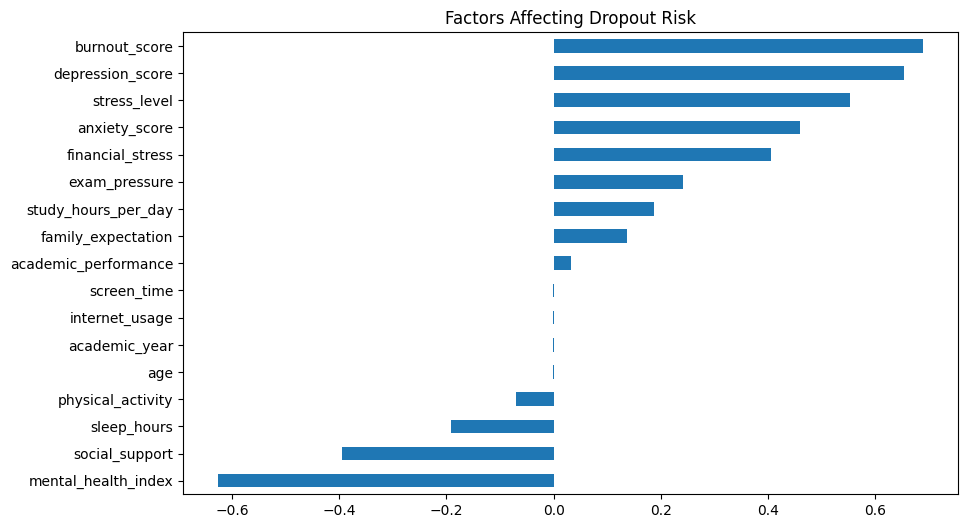

In [30]:
# Droupout Factors
dropout_corr.drop(
    "dropout_risk"
).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Factors Affecting Dropout Risk")
plt.show()

In [31]:
# mental helth strongest relationships with other factors
corr["mental_health_index"]\
.sort_values(
    key=abs,
    ascending=False
)\
.head(10)

,mental_health_index
mental_health_index,1.000000
stress_level,-0.949370
anxiety_score,-0.868516
burnout_score,-0.796325
depression_score,-0.762942
dropout_risk,-0.625633
financial_stress,-0.442884
exam_pressure,-0.435511
study_hours_per_day,-0.335765
family_expectation,-0.328537


In [32]:
top_factors = corr["dropout_risk"]\
    .sort_values(
        key=abs,
        ascending=False
    )

top_factors.head(10)

,dropout_risk
dropout_risk,1.000000
burnout_score,0.689047
depression_score,0.654250
mental_health_index,-0.625633
stress_level,0.553389
anxiety_score,0.460329
financial_stress,0.405950
social_support,-0.395256
exam_pressure,0.242376
sleep_hours,-0.191317


### Key Insight

Burnout, depression, stress, and financial stress were the strongest predictors of dropout risk.

## Student Segmentation Based on Stress Levels

In [33]:
df["stress_group"] = pd.cut(
    df["stress_level"],
    bins=[0,3,6,10],
    labels=["Low Stress","Medium Stress","High Stress"]
)

In [34]:
df.groupby("stress_group")[
    ["mental_health_index",
     "burnout_score",
     "dropout_risk"]
].mean()

/tmp/ipykernel_1905/3638680751.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stress_group")[


,mental_health_index,burnout_score,dropout_risk
stress_group,,,
Low Stress,8.612936,0.321328,0.501380
Medium Stress,6.889638,1.817254,1.332858
High Stress,5.013496,4.030345,2.749214


/tmp/ipykernel_1905/3399602168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_profile = df.groupby("stress_group")[


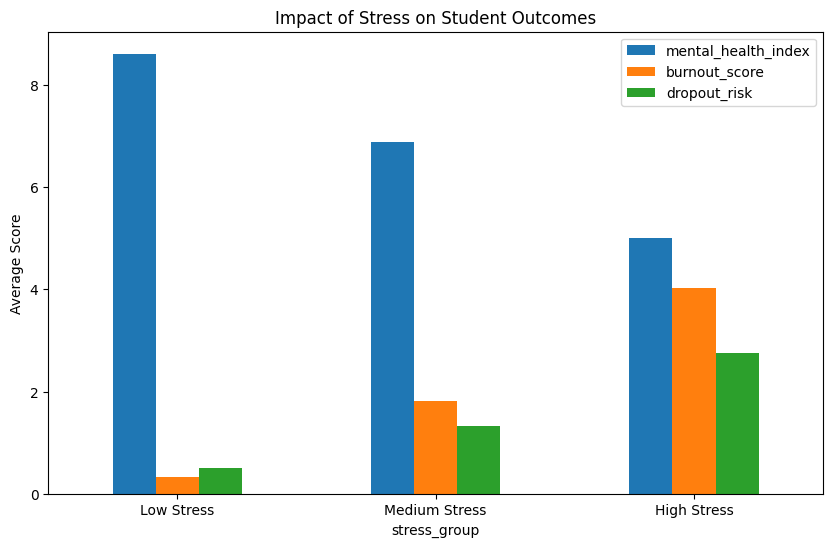

In [35]:
stress_profile = df.groupby("stress_group")[
    ["mental_health_index",
     "burnout_score",
     "dropout_risk"]
].mean()

stress_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Impact of Stress on Student Outcomes")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

### Key Insight

Students in the high-stress group exhibited dramatically lower mental health scores, significantly higher burnout levels, and substantially greater dropout risk compared to low-stress students.

# Conclusion

This project investigated the factors affecting student mental health, burnout, and dropout risk using exploratory data analysis on a large student well-being dataset.


## Summary of Findings

1. Stress level was the strongest factor affecting mental health.

2. Anxiety, depression, and burnout showed strong negative relationships with student well-being.

3. Burnout was the strongest predictor of dropout risk.

4. Financial stress contributed to both poorer mental health and higher dropout risk.

5. Sleep and physical activity demonstrated positive relationships with student well-being.

6. Social support reduced dropout risk and acted as a protective factor.

7. Screen time and internet usage showed little measurable impact on mental health outcomes.

## Recommendations

Educational institutions should prioritize:

- Stress-management programs
- Mental health counseling services
- Burnout prevention initiatives
- Financial assistance programs
- Peer-support and mentoring systems

Addressing these factors may improve student well-being and reduce the likelihood of academic burnout and dropout.